In [28]:
import matplotlib.pyplot as plt
import pandas as pd
import pathlib as path
import numpy as np

In [2]:
parent_dir = path.Path.cwd().parent
data = pd.read_csv(parent_dir / "data" / "properties_2016_raw.csv",
                   dtype={
                        'hashottuborspa': 'string',
                        'propertycountylandusecode': 'string',
                        'propertyzoningdesc': 'string',
                        'fireplaceflag': 'string',
                        'taxdelinquencyflag': 'string',
                        }
)

In [3]:
print(data.columns)

Index(['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid',
       'basementsqft', 'bathroomcnt', 'bedroomcnt', 'buildingclasstypeid',
       'buildingqualitytypeid', 'calculatedbathnbr', 'decktypeid',
       'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet',
       'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15',
       'finishedsquarefeet50', 'finishedsquarefeet6', 'fips', 'fireplacecnt',
       'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
       'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'rawcensustractandblock', 'regionidcity',
       'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt',
       'storytypeid', 'threequarterbathnbr', 'typeconstructiontypeid',
       'unitcnt', 'yardbuildingsqft17', 'yardbuildin

In [36]:
cols = ["taxvaluedollarcnt", "taxdelinquencyflag", "taxdelinquencyyear", "latitude", "longitude"]
tax_data = data[cols].fillna(value={"taxdelinquencyflag": "N", "taxdelinquencyyear": 0}).sort_values(by=['taxvaluedollarcnt', 'taxdelinquencyyear']).reset_index(drop=True)

late = tax_data[tax_data['taxdelinquencyflag'] == 'Y']
punctual = tax_data.drop(index = late.index)

tax_data.describe()
late["taxdelinquencyyear"].sort_values().unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 79., 82., 84., 86., 87., 88., 90., 91., 92., 93., 94.,
       95., 96., 97., 98., 99.])

In [69]:
data["parcelid"].unique()

array([ 10754147,  10759547,  10843547, ..., 168040630, 168040830,
       168040430], shape=(2985217,))

In [37]:
late.describe()
tax_data.shape[0] / 56462

52.87125854557047

In [7]:
N = 50
years_late = np.array(tax_data['taxdelinquencyyear'])
cum_years_late = np.cumsum(years_late)
rolling_late_avg = (cum_years_late[N:] - cum_years_late[:-N])/N
rolling_late_avg

array([0.  , 0.  , 0.  , ..., 2.4 , 2.68, 2.96], shape=(2985167,))

In [8]:
tax_data_cut = tax_data.iloc[N:].reset_index(drop=True)
tax_data_cut

,taxvaluedollarcnt,taxdelinquencyflag,taxdelinquencyyear,latitude,longitude
0,9.0,N,0.0,34008079.0,-118062282.0
1,9.0,N,0.0,34068910.0,-118017674.0
2,9.0,N,0.0,34261228.0,-118541484.0
3,9.0,N,0.0,34407859.0,-118453553.0
4,9.0,N,0.0,34009287.0,-118387430.0
...,...,...,...,...,...
2985162,NaN,Y,14.0,34180953.0,-118863884.0
2985163,NaN,Y,14.0,34439349.0,-119163041.0
2985164,NaN,Y,14.0,34238443.0,-119183793.0
2985165,NaN,Y,14.0,34283545.0,-119269066.0


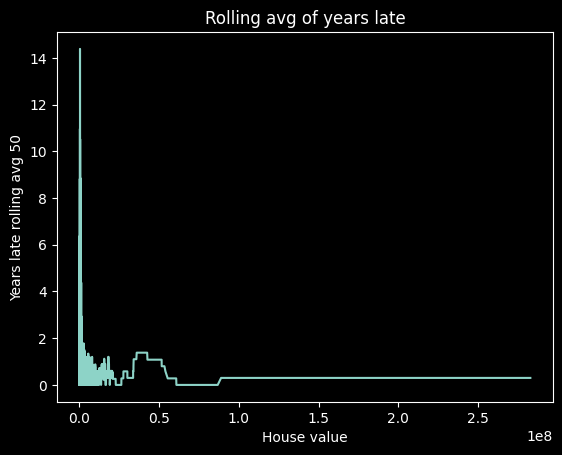

In [9]:
plt.plot(tax_data_cut['taxvaluedollarcnt'], rolling_late_avg)

plt.title("Rolling avg of years late")
plt.xlabel("House value")
plt.ylabel("Years late rolling avg 50")

plt.show()

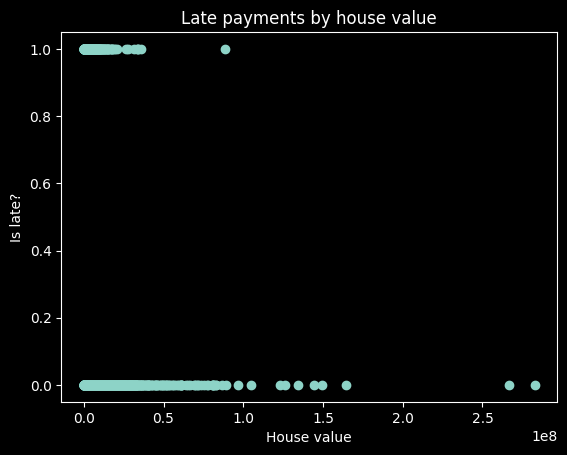

In [10]:
plt.scatter(tax_data["taxvaluedollarcnt"], tax_data["taxdelinquencyflag"].replace({"N": 0, "Y": 1}))

plt.title("Late payments by house value")
plt.xlabel("House value")
plt.ylabel("Is late?")

plt.show()

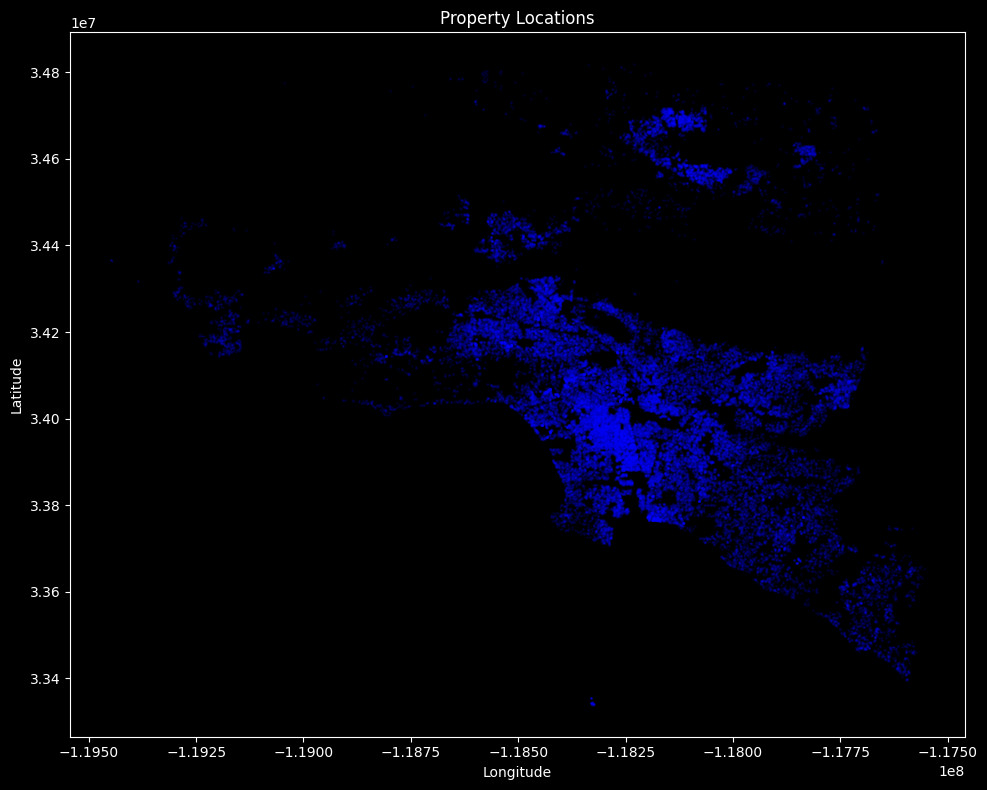

In [12]:
plt.figure(figsize=(10, 8))

# s=1 makes the dots tiny, alpha=0.1 makes them transparent
plt.scatter(late["longitude"], late["latitude"], s=1, alpha=0.1, color='blue')

plt.title("Property Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

In [34]:
not_late = tax_data[tax_data['taxdelinquencyflag'] == 'N']
late_1st_group = tax_data[(tax_data['taxdelinquencyyear'] >= 1) & (tax_data['taxdelinquencyyear'] <= 5)]
late_2nd_group = tax_data[(tax_data['taxdelinquencyyear'] >= 6) & (tax_data['taxdelinquencyyear'] <= 10)]
late_3rd_group = tax_data[(tax_data['taxdelinquencyyear'] >= 11) & (tax_data['taxdelinquencyyear'] <= 15)]
late_last_group = tax_data[tax_data['taxdelinquencyyear'] >= 16]
tax_data.drop(index=not_late.index).drop(index = late_1st_group.index).shape

(56412, 5)

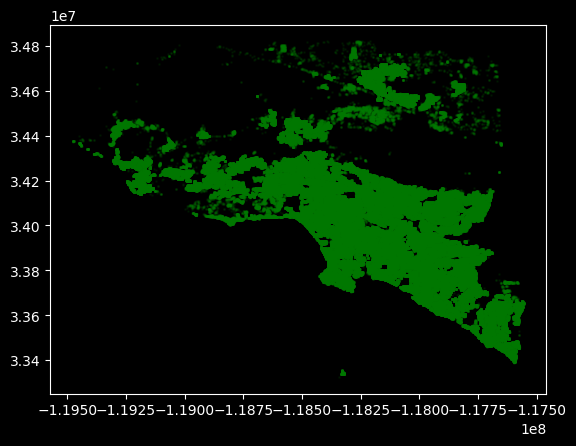

In [23]:
plt.scatter(not_late["longitude"], not_late["latitude"], s=1, alpha=0.1, color='green')

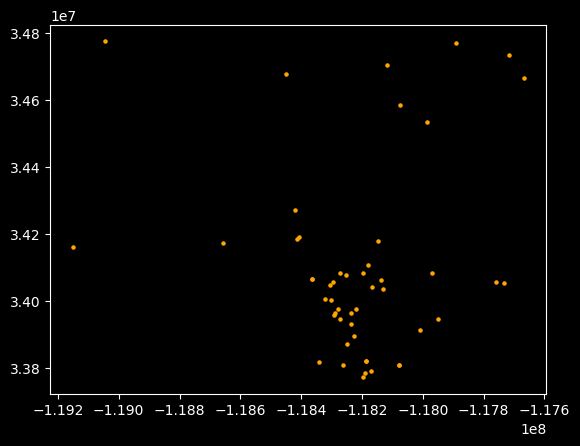

In [45]:
plt.scatter(late_1st_group["longitude"], late_1st_group["latitude"], s=5, alpha=1, color="orange")
plt.show()

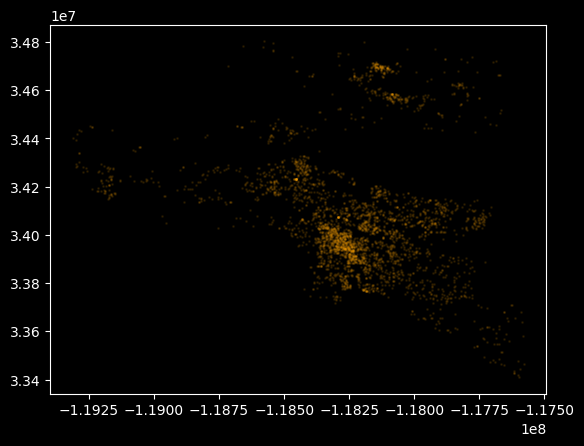

In [64]:
plt.scatter(late_2nd_group["longitude"], late_2nd_group["latitude"], s=1, alpha=0.1, color="orange")

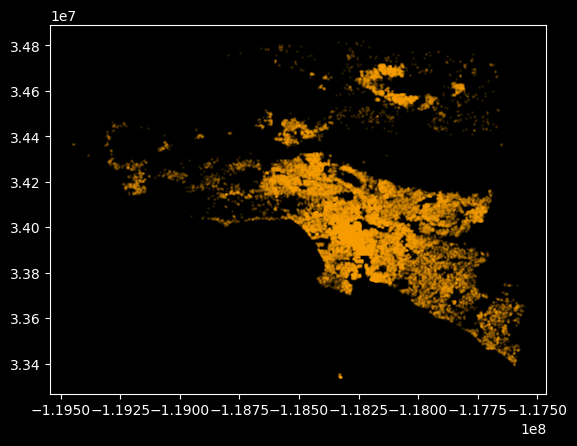

In [63]:
plt.scatter(late_3rd_group["longitude"], late_3rd_group["latitude"], s=1, alpha=0.1, color="orange")

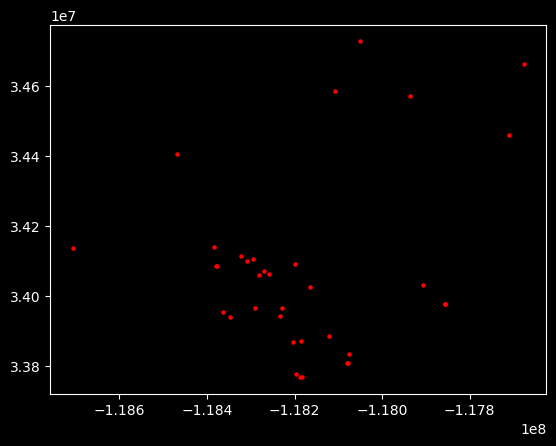

In [72]:
plt.scatter(late_last_group["longitude"], late_last_group["latitude"], s=5, alpha=1, color="red")